## Support Vector Classifier Implementation

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
from sklearn.datasets import make_classification

In [35]:
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [36]:
df =pd.DataFrame(x)

<Axes: xlabel='0', ylabel='1'>

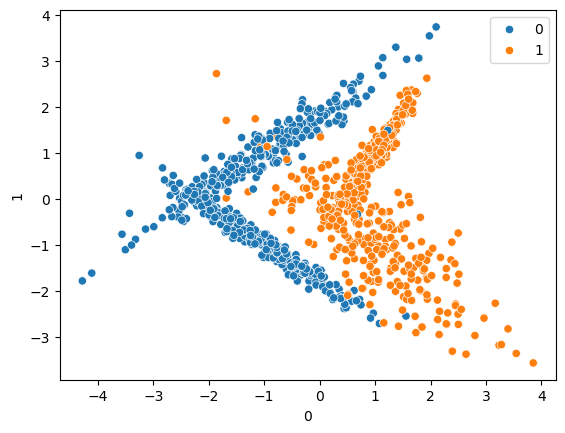

In [37]:
sns.scatterplot(
    x=df[0],
    y=df[1],
    hue=y
)

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)

In [39]:
from sklearn.svm import SVC


In [40]:
svc=SVC(kernel='linear')

In [41]:
svc.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
y_pred=svc.predict(x_test)

In [43]:
from sklearn.metrics import classification_report,confusion_matrix

In [44]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       124
           1       0.86      0.94      0.90       126

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[105  19]
 [  7 119]]


In [46]:
rbf=SVC(kernel='rbf')

In [47]:
rbf.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [48]:
y_pred1=rbf.predict(x_test)

In [49]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       124
           1       0.98      0.98      0.98       126

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250

[[122   2]
 [  2 124]]


In [50]:
polynomial=SVC(kernel='polynomial')
rbf.fit(x_train,y_train)
y_pred_polynomial=rbf.predict(x_test)
print(classification_report(y_test,y_pred_polynomial))
print(confusion_matrix(y_test,y_pred_polynomial))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       124
           1       0.98      0.98      0.98       126

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250

[[122   2]
 [  2 124]]


In [51]:
sigmoid=SVC(kernel='sigmoid')
rbf.fit(x_train,y_train)
y_pred_sigmoid=rbf.predict(x_test)
print(classification_report(y_test,y_pred_sigmoid))
print(confusion_matrix(y_test,y_pred_sigmoid))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       124
           1       0.98      0.98      0.98       126

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250

[[122   2]
 [  2 124]]


In [55]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'C' : [0.1,1,10,100,1000],
    'gamma' : [1,0.1,0.01,0.001,0.0001],
    'kernel' : ['rbf']
}

In [56]:
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    verbose=3
)


In [57]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.833 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [58]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [59]:
y_pred_grid=grid.predict(x_test)
print(classification_report(y_test,y_pred_grid))
print(confusion_matrix(y_test,y_pred_grid))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       124
           1       0.98      0.98      0.98       126

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250

[[122   2]
 [  2 124]]
